In [1]:
import matplotlib.pyplot as plt

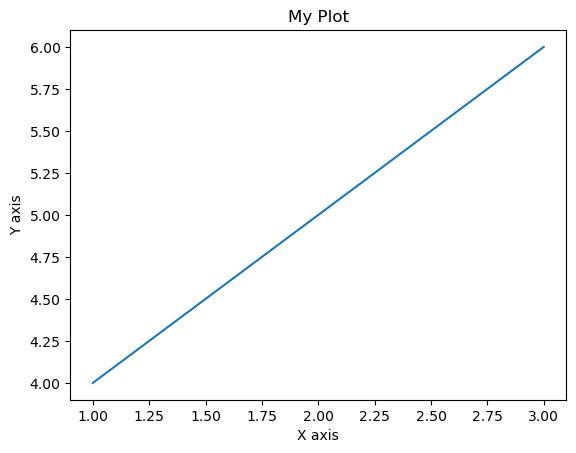

In [3]:
plt.plot([1,2,3], [4,5,6])
ax = plt.gca()   # get the current axes
ax.set_title("My Plot")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
plt.show()

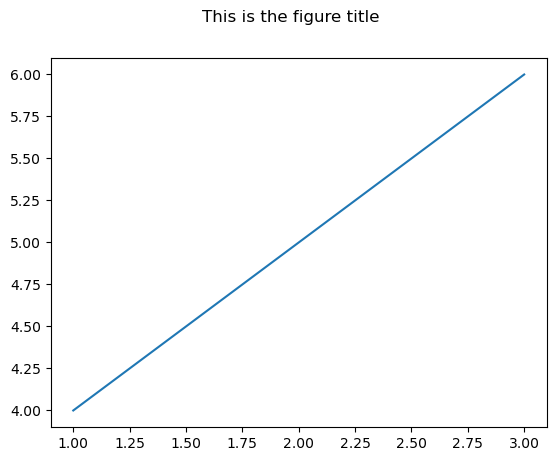

In [4]:
plt.plot([1,2,3], [4,5,6])
fig = plt.gcf()   # get the current figure
fig.suptitle("This is the figure title")
plt.show()

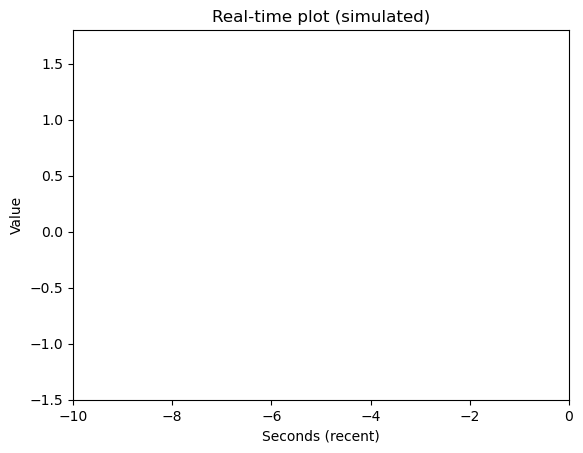

In [9]:
# In a Jupyter cell, run ONE of these first:
# %matplotlib notebook   # good interactive backend
# or
# %matplotlib widget     # needs ipywidgets installed
# (As a fallback, %matplotlib inline will show frames but may look choppy.)

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from matplotlib.animation import FuncAnimation
import time

HISTORY_SEC = 10
FPS = 30
MAXLEN = HISTORY_SEC * FPS

rng = np.random.default_rng(42)
xbuf = deque(maxlen=MAXLEN)
ybuf = deque(maxlen=MAXLEN)

fig, ax = plt.subplots()
(line,) = ax.plot([], [])
ax.set_xlim(-HISTORY_SEC, 0)
ax.set_ylim(-1.5, 1.8)
ax.set_xlabel("Seconds (recent)")
ax.set_ylabel("Value")
ax.set_title("Real-time plot (simulated)")

t0 = time.time()
_spike_state = 0.0

def get_new_sample():
    global _spike_state
    t = time.time() - t0
    base = np.sin(2*np.pi*0.5*t) + 0.25*np.sin(2*np.pi*2.0*t) + 0.06*rng.normal()
    if rng.random() < 0.01:
        _spike_state += rng.normal(loc=1.2, scale=0.3)
    _spike_state *= 0.92
    return t, base + _spike_state

def update(_):
    t, y = get_new_sample()
    xbuf.append(t); ybuf.append(y)
    x = np.fromiter(xbuf, float); yarr = np.fromiter(ybuf, float)
    x = x - x[-1]
    line.set_data(x, yarr)
    return (line,)

# NOTE: blit=False is important in many notebook backends
ani = FuncAnimation(fig, update, interval=1000//FPS, blit=False, cache_frame_data=False)

plt.show()

# Keep a reference to `ani` in a global variable or the cell's scope (as above)


